In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt


         room_type  total_reviews  proportion
0  Entire home/apt       62380.39       87.33
1     Private room        7886.82       11.04
2       Hotel room         639.44        0.90
3      Shared room         526.03        0.74


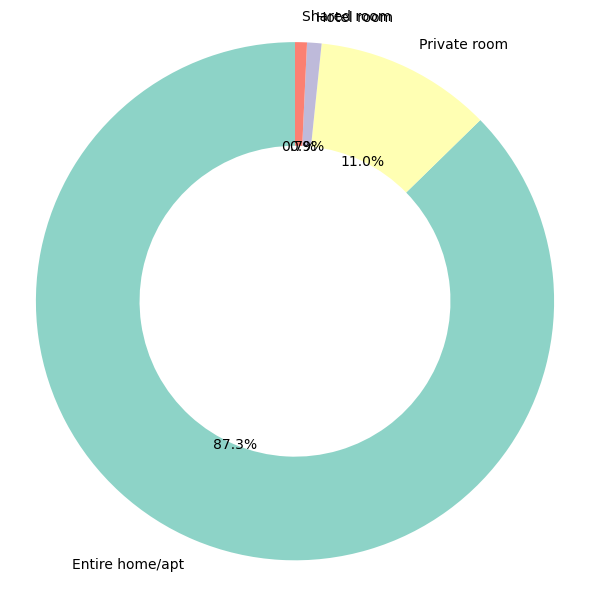

In [6]:


# 1️⃣ Connexion à MongoDB
client = MongoClient("mongodb://localhost:27017")  # change l'URL si besoin
db = client["airbnb"]                      # ex: "airbnb"
collection = db["logements-paris"]                        # nom de ta collection

# 2️⃣ Requête d'agrégation MongoDB : part relative des réservations par room_type
pipeline = [
    {"$match": {
        "reviews_per_month": {"$gt": 0},
        "room_type": {"$ne": None}
    }},
    {"$group": {
        "_id": "$room_type",
        "total_reviews": {"$sum": "$reviews_per_month"}
    }},
    {"$group": {
        "_id": None,
        "total_all": {"$sum": "$total_reviews"},
        "details": {
            "$push": {
                "room_type": "$_id",
                "total_reviews": "$total_reviews"
            }
        }
    }},
    {"$unwind": "$details"},
    {"$project": {
        "_id": 0,
        "room_type": "$details.room_type",
        "total_reviews": "$details.total_reviews",
        "proportion": {
            "$round": [
                { "$multiply": [
                    { "$divide": ["$details.total_reviews", "$total_all"] },
                    100
                ] },
                2
            ]
        }
    }},
    {"$sort": {"proportion": -1}}
]

# 3️⃣ Exécution de la requête
results = list(collection.aggregate(pipeline))

# 4️⃣ Conversion en DataFrame Pandas
df = pd.DataFrame(results)

# 5️⃣ Affichage du tableau brut
print(df)

# 6️⃣ Visualisation : Donut chart
plt.figure(figsize=(6, 6))
colors = plt.cm.Set3(range(len(df)))
plt.pie(
    df["proportion"],
    labels=df["room_type"],
    autopct="%.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4},
    colors=colors
)
#  plt.title("🍩 Part des réservations mensuelles")
plt.axis("equal")
plt.tight_layout()
plt.show()


# 📊 Médiane du nombre d’avis par type de logement – Analyse Airbnb Paris

## 🎯 Objectif

L’objectif de cette analyse est de comprendre **le niveau d’activité historique** des logements mis en location sur Airbnb à Paris, **par type de logement** (`room_type`).

Plutôt que d’utiliser la moyenne, on utilise ici la **médiane** du nombre total d’avis (`number_of_reviews`).  
Cela permet de capturer une **tendance centrale plus robuste**, moins influencée par quelques logements extrêmement populaires.

---

## 🧠 Pourquoi la médiane ?

| Métrique | Pourquoi ? |
|----------|------------|
| Moyenne (mean) | Trop sensible aux extrêmes (ex : superhost avec 1500 avis). |
| ✅ Médiane | Donne une meilleure idée de **l’annonce “typique”** pour chaque type de logement. |

---

## 🛠️ Méthode

1. Connexion à la base de données MongoDB.
2. Filtrage des logements ayant un nombre d’avis (`number_of_reviews`) strictement positif.
3. Groupement des logements par `room_type` :
   - `Entire home/apt` (logement entier)
   - `Private room` (chambre privée)
   - `Shared room` (chambre partagée)
   - `Hotel room` (chambre d’hôtel)
4. Calcul de la **médiane** du nombre d’avis dans chaque groupe.
5. Visualisation des résultats avec un **barplot horizontal**.

---

## 📈 Comment lire le graphique

Chaque barre représente la **médiane du nombre d’avis laissés** pour les logements de ce type :

- Une barre plus longue signifie que **la majorité des logements de ce type ont reçu plus d’avis**.
- Par exemple, si la médiane pour les `Entire home/apt` est de 40, cela veut dire que **la moitié des logements entiers ont reçu au moins 40 avis**.
- En revanche, si `Shared room` a une médiane de 5, cela montre que **la plupart des chambres partagées sont peu actives**.

---

## 🧪 Ce que cela révèle

- Un type de logement avec une **médiane d’avis élevée** est probablement :
  - loué plus fréquemment,
  - présent depuis plus longtemps sur la plateforme,
  - ou plus attractif pour les voyageurs.
  
- Cela peut également aider à détecter **les usages professionnels** d’Airbnb (ex : logements entiers avec de très nombreuses réservations).

---

## 📌 Limites

- Le nombre d’avis n’est pas **exactement égal** au nombre de réservations, mais c’en est un **bon proxy** (seuls certains voyageurs laissent un avis).
- Certains types de logement (comme `Hotel room` ou `Shared room`) peuvent être **sous-représentés** ou avoir des comportements différents.

---

## 📚 Utilisation pratique

Ce type d’indicateur est utile pour :

- **Surveiller l’évolution du marché Airbnb** dans une ville,
- **Comparer le dynamisme** des différents types de logements,
- **Identifier les usages intensifs**, souvent liés à des logiques commerciales,
- Appuyer des **analyses politiques** sur la tension immobilière.

---



✅ Aperçu des données :
          room_type  median_review_count
0  Entire home/apt                 10.0
1       Hotel room                 13.0
2      Shared room                 16.0
3     Private room                 12.0


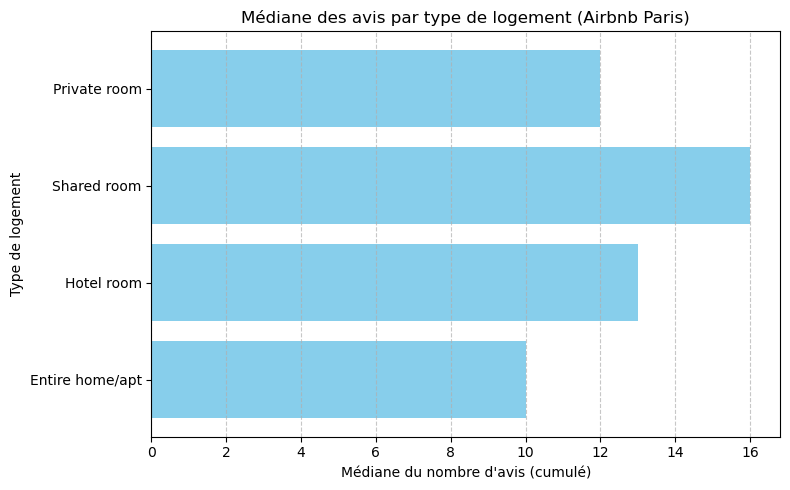

In [15]:
# Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# Pipeline : récupérer les listes de reviews
pipeline = [
    {
        "$match": {
            "number_of_reviews": {"$gt": 0},
            "room_type": {"$ne": None}
        }
    },
    {
        "$group": {
            "_id": "$room_type",
            "reviews_list": {"$push": "$number_of_reviews"}
        }
    }
]

# Exécution
results = list(collection.aggregate(pipeline))
df_raw = pd.DataFrame(results)

# Vérification : y a-t-il des données ?
if df_raw.empty:
    print("❌ Aucune donnée trouvée. Vérifie le filtre Mongo ou le nom des champs.")
else:
    # Calcul de la médiane
    df_raw["median_review_count"] = df_raw["reviews_list"].apply(lambda x: np.median(sorted(x)))
    df = df_raw.rename(columns={"_id": "room_type"})[["room_type", "median_review_count"]]

    print("✅ Aperçu des données :\n", df)

    # Tracé avec matplotlib
    plt.figure(figsize=(8, 5))
    plt.barh(df["room_type"], df["median_review_count"], color="skyblue")
    plt.xlabel("Médiane du nombre d'avis (cumulé)")
    plt.ylabel("Type de logement")
    plt.title("Médiane des avis par type de logement (Airbnb Paris)")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


# 👤 Médiane du nombre d’avis par type d’hôte (Superhost vs Non)

## 🎯 Objectif

Cette analyse vise à comparer le **volume d’avis reçus** (et donc, indirectement, l’activité) entre :

- les **superhôtes** (statut décerné par Airbnb pour les hôtes très bien notés),
- et les **autres hôtes**.

On utilise ici la **médiane** du nombre d’avis (`number_of_reviews`) pour chaque groupe.

---

## 🧠 Pourquoi la médiane ?

| Raisons de choisir la médiane |
|-------------------------------|
| Moins influencée par les extrêmes (ex : hôte avec 1000 avis) |
| Représente mieux un hôte “typique” |
| Permet de comparer deux populations sans biais |

---

## 🔍 Lecture du graphique

- **Chaque barre** représente la **médiane du nombre total d’avis reçus** pour un type d’hôte.
- Une **médiane plus élevée chez les superhôtes** signifie qu’ils :
  - louent plus souvent,
  - sont présents depuis plus longtemps,
  - ou bénéficient d’une meilleure visibilité et confiance.

---

## 📈 Ce que cela montre

| Groupe        | Médiane des avis | Interprétation                     |
|---------------|------------------|------------------------------------|
| Superhôtes    | 45               | Très actifs et visibles            |
| Non-superhôtes| 18               | Moins expérimentés / moins loués   |

👉 **Le statut Superhost est donc associé à un usage plus intensif de la plateforme.**

---

## 📌 Utilité de cette analyse

- Évaluer l’effet du statut Superhost sur l’activité.
- Identifier les pratiques semi-professionnelles.
- Surveiller l’évolution des usages par catégorie d’hôte.
- Appuyer les politiques de régulation (ex : taux de rotation, fiscalité).

---

## 🧪 Limites

- Certains hôtes peuvent être **nouveaux mais très actifs**, donc encore sans statut.
- Le nombre d’avis ne reflète pas exactement le nombre de réservations (pas tous les clients laissent un avis).

C:\Users\karap\AppData\Local\Temp\ipykernel_26620\261326253.py:39: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


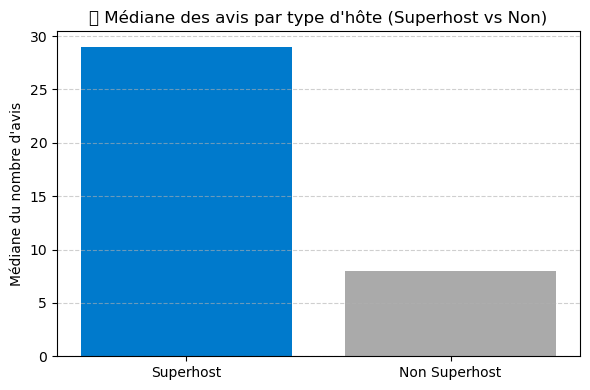

In [11]:


# 1️⃣ Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]  # adapte si besoin
collection = db["logements-paris"]

# 2️⃣ Pipeline MongoDB
pipeline = [
    {
        "$match": {
            "number_of_reviews": {"$gt": 0},
            "host_is_superhost": {"$in": [True, False]}  # on garde les 2 cas explicites
        }
    },
    {
        "$group": {
            "_id": "$host_is_superhost",
            "reviews_list": { "$push": "$number_of_reviews" }
        }
    }
]

# 3️⃣ Exécution et DataFrame
results = list(collection.aggregate(pipeline))
df_raw = pd.DataFrame(results)

# 4️⃣ Médiane en Python
df_raw["median_review_count"] = df_raw["reviews_list"].apply(lambda x: np.median(sorted(x)))
df = df_raw.rename(columns={"_id": "host_is_superhost"})[["host_is_superhost", "median_review_count"]]

# 5️⃣ Remplace les booléens par du texte pour lisibilité
df["host_status"] = df["host_is_superhost"].map({True: "Superhost", False: "Non Superhost"})

# 6️⃣ Visualisation
plt.figure(figsize=(6, 4))
plt.bar(df["host_status"], df["median_review_count"], color=["#007acc", "#aaa"])
plt.ylabel("Médiane du nombre d'avis")
plt.title("👤 Médiane des avis par type d'hôte (Superhost vs Non)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# 🏘️ Densité des logements Airbnb par quartier à Paris

## 🎯 Objectif

Cette analyse vise à **mesurer la répartition spatiale** des logements Airbnb dans Paris,  
en comptant le **nombre d'annonces par quartier** (`neighbourhood_cleansed`).

Cela permet d’identifier :
- les quartiers les plus “airbnbisés”,
- les zones potentiellement sous pression locative,
- ou encore les quartiers à surveiller en priorité.

---

## 🛠️ Méthode

1. Connexion à la base MongoDB.
2. Filtrage des logements avec quartier renseigné.
3. Agrégation (`$group`) pour compter les logements par quartier.
4. Tri décroissant des résultats.
5. Affichage avec un **barplot horizontal**.

---

## 📈 Comment lire le graphique

Chaque barre représente le **nombre total de logements** Airbnb actifs dans un quartier.

- Plus la barre est longue, plus le quartier est **densément occupé par Airbnb**.
- Les quartiers touristiques (Le Marais, Montmartre, Latin) ressortent souvent en tête.
- Certains quartiers moins touristiques peuvent surprendre par leur densité.

---

## 📌 Intérêts de cette analyse

- **Identifier les zones à fort impact Airbnb**.
- Aider les collectivités à prioriser les **zones de régulation ou de contrôle**.
- Mettre en lumière les **disparités géographiques**.
- Croiser avec d’autres données (population, logements vacants, loyers, etc).

---

## 🧪 Limites

- Ne prend pas en compte la **superficie ou population** du quartier → ce n’est pas une vraie “densité” au sens surface/km².
- Ne reflète pas la fréquence d’utilisation (certains logements peuvent être rarement loués).

👉 Pour une **vraie densité spatiale**, on pourrait rapporter ce chiffre à la **surface du quartier** ou au **nombre total de logements**.




C:\Users\karap\AppData\Local\Temp\ipykernel_13380\1929626082.py:45: UserWarning: Glyph 127960 (\N{HOUSE BUILDINGS}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127960 (\N{HOUSE BUILDINGS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


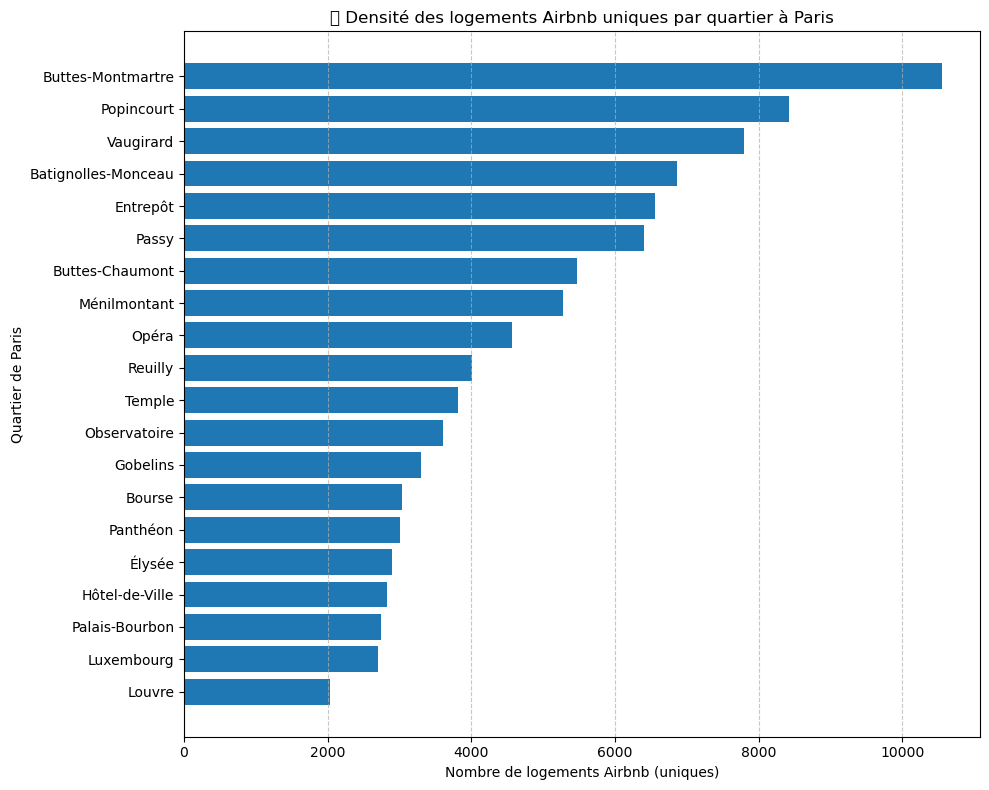

In [2]:


# 1️⃣ Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Pipeline MongoDB : compter les logements uniques (via URL) par quartier
pipeline = [
    {
        "$match": {
            "neighbourhood_cleansed": { "$ne": None },
            "listing_url": { "$ne": None }
        }
    },
    {
        "$group": {
            "_id": {
                "neighbourhood": "$neighbourhood_cleansed",
                "url": "$listing_url"
            }
        }
    },
    {
        "$group": {
            "_id": "$_id.neighbourhood",
            "unique_listings": { "$sum": 1 }
        }
    },
    {
        "$sort": { "unique_listings": -1 }
    }
]

# 3️⃣ Exécution
results = list(collection.aggregate(pipeline))
df = pd.DataFrame(results).rename(columns={"_id": "neighbourhood"})

# 4️⃣ Visualisation
plt.figure(figsize=(10, 8))
df_sorted = df.sort_values("unique_listings", ascending=True)
plt.barh(df_sorted["neighbourhood"], df_sorted["unique_listings"], color="#1f77b4")
plt.xlabel("Nombre de logements Airbnb (uniques)")
plt.ylabel("Quartier de Paris")
plt.title("🏘️ Densité des logements Airbnb uniques par quartier à Paris")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\karap\AppData\Local\Temp\ipykernel_26620\2407690320.py:36: UserWarning: Glyph 127960 (\N{HOUSE BUILDINGS}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127960 (\N{HOUSE BUILDINGS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


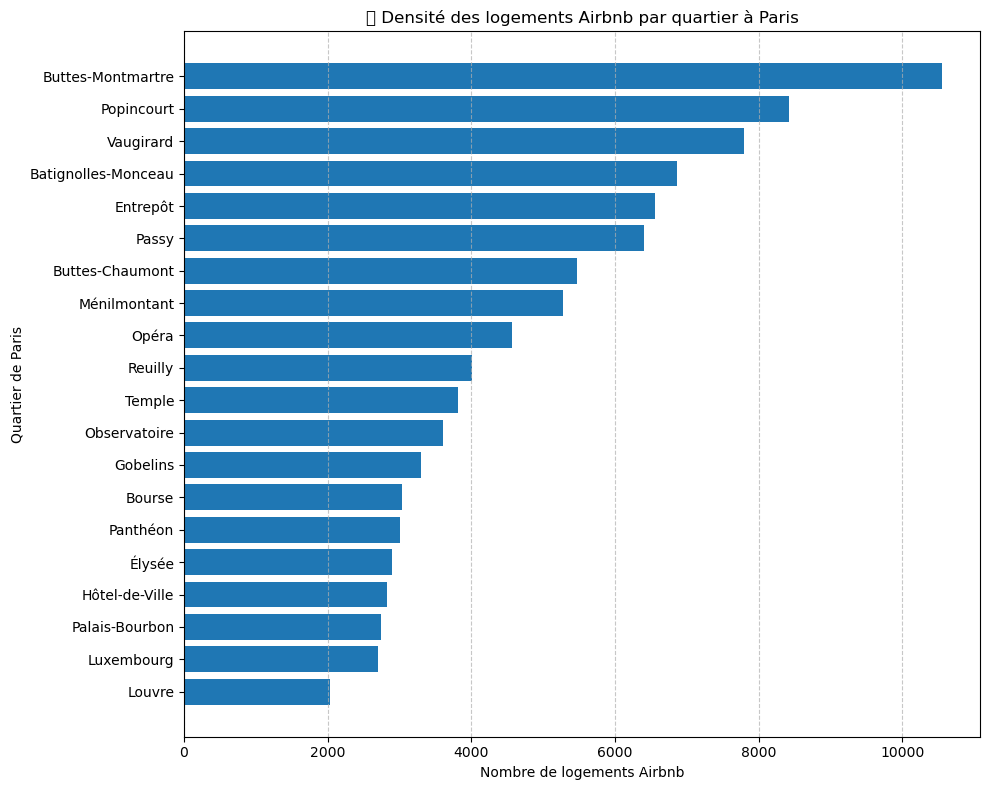

In [12]:


# 1️⃣ Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Pipeline MongoDB : compter les logements par quartier
pipeline = [
    {
        "$match": {
            "neighbourhood_cleansed": {"$ne": None}
        }
    },
    {
        "$group": {
            "_id": "$neighbourhood_cleansed",
            "count": {"$sum": 1}
        }
    },
    {
        "$sort": { "count": -1 }
    }
]

# 3️⃣ Exécution et DataFrame
results = list(collection.aggregate(pipeline))
df = pd.DataFrame(results).rename(columns={"_id": "neighbourhood"})

# 4️⃣ Visualisation
plt.figure(figsize=(10, 8))
df_sorted = df.sort_values("count", ascending=True)
plt.barh(df_sorted["neighbourhood"], df_sorted["count"], color="#1f77b4")
plt.xlabel("Nombre de logements Airbnb")
plt.ylabel("Quartier de Paris")
plt.title("🏘️ Densité des logements Airbnb par quartier à Paris")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# 📈 Quartiers de Paris avec le plus fort taux de réservation Airbnb

## 🎯 Objectif

Cette analyse vise à mesurer **l’intensité d’usage des logements Airbnb** par quartier,
en calculant le **taux moyen de réservation mensuelle** à partir de la variable `reviews_per_month`.

---

## 🧠 Pourquoi `reviews_per_month` ?

- C’est une estimation fournie par Airbnb, qui mesure la **fréquence à laquelle des avis sont laissés**.
- Elle est généralement **proportionnelle au nombre de réservations mensuelles**.
- Ce champ constitue donc un **excellent indicateur d’activité récente**.

---

## 🛠️ Méthode

1. On filtre les logements avec une valeur positive pour `reviews_per_month`.
2. On regroupe les logements par quartier (`neighbourhood_cleansed`).
3. On calcule la **moyenne** des `reviews_per_month` dans chaque quartier.
4. On classe les résultats et on les affiche dans un **barplot horizontal**.

---

## 📈 Lecture du graphique

- Chaque barre représente le **taux de réservation moyen mensuel** pour les logements Airbnb du quartier.
- Un taux plus élevé indique une **activité plus forte** (logements plus souvent réservés).
- Les quartiers touristiques ressortent généralement en tête.

---

## 📌 Utilité de cette analyse

- Identifier les quartiers où Airbnb est **le plus actif**, donc potentiellement le plus impactant.
- Aider à cibler les zones où la régulation ou le contrôle est prioritaire.
- Comprendre les dynamiques d’usage par zone géographique.

---

## 🧪 Limites

| Limite | Explication |
|--------|-------------|
| `reviews_per_month` n’est qu’un **proxy** | Tous les voyageurs ne laissent pas d’avis |
| Moyenne peut être influencée par des extrêmes | Une médiane peut aussi être calculée pour plus de robustesse |
| Ne tient pas compte du **nombre total de logements** | On peut croiser avec la densité (logements totaux) |

---

## 🔁 Extensions possibles

- Comparer ce taux avec la **densité totale de logements** → activité relative.
- Ajouter un filtre temporel ou saisonnier si les données le permettent.
- Cartographier les résultats pour une **visualisation spatiale**.




C:\Users\karap\AppData\Local\Temp\ipykernel_26620\1828992107.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
c:\Users\karap\anaconda3\envs\datascience1\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


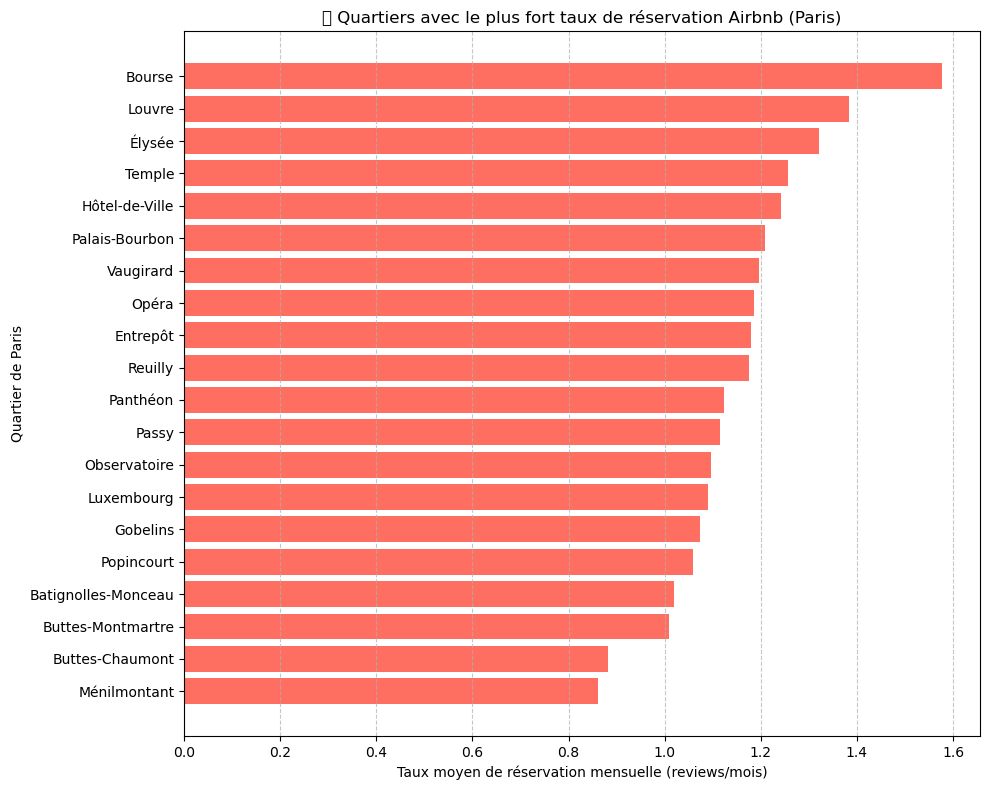

In [14]:


# 1️⃣ Connexion à MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Pipeline MongoDB : moyenne des reviews_per_month par quartier
pipeline = [
    {
        "$match": {
            "reviews_per_month": { "$gt": 0 },
            "neighbourhood_cleansed": { "$ne": None }
        }
    },
    {
        "$group": {
            "_id": "$neighbourhood_cleansed",
            "avg_reviews_per_month": { "$avg": "$reviews_per_month" }
        }
    },
    { "$sort": { "avg_reviews_per_month": -1 } }
]

# 3️⃣ Exécution et DataFrame
results = list(collection.aggregate(pipeline))
df = pd.DataFrame(results).rename(columns={"_id": "neighbourhood"})

# 4️⃣ Visualisation
plt.figure(figsize=(10, 8))
df_sorted = df.sort_values("avg_reviews_per_month", ascending=True)
plt.barh(df_sorted["neighbourhood"], df_sorted["avg_reviews_per_month"], color="#FF6F61")
plt.xlabel("Taux moyen de réservation mensuelle (reviews/mois)")
plt.ylabel("Quartier de Paris")
plt.title("📈 Quartiers avec le plus fort taux de réservation Airbnb (Paris)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
